# Random FDLU noising arbitrary sites

Created: 07-07-2026

Objectives:
* Build off [previous notebook](random_fdlu_noising_arbitrary_sites.ipynb), but now want to get working for depth 2 FDLU.

# Imports

In [1]:
import numpy as np

In [2]:
import jax
jax.config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp

In [3]:
import matplotlib.pyplot as plt

In [4]:
from tqdm import tqdm

In [5]:
from functools import reduce

In [6]:
import quimb.tensor as qtn
import quimb as qu

In [7]:
from scipy.stats import ortho_group

In [8]:
from collections import Counter

In [9]:
import pandas as pd

In [10]:
from time import time

# Definitions
## Construct cluster state

In [11]:
np_up_X_state = 1/(np.sqrt(2))*np.array([1,1])

In [12]:
qu_up_X_state = qtn.Tensor(
    data=np_up_X_state,
    inds=('k',),
    tags='prod'
)

In [13]:
np_CZ = np.diag([1,1,1,-1])

In [14]:
np_CZ = np_CZ.reshape((2,)*4)

In [15]:
qu_CZ = qtn.Tensor(
    data=np_CZ,
    inds=('k1', 'k2', 'b1', 'b2'),
    tags='CZ'
)

In [16]:
def get_cluster_state_qu_tensor_network(num_sites):
    assert (num_sites%2) == 0

    product_state_tensors = [
        qu_up_X_state.reindex({'k': f'kc_1_{i}'})
        for i in range(num_sites)
    ]

    first_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_1_{i}',
            'b2': f'kc_1_{i+1}',
            'k1': f'kc_2_{i}',
            'k2': f'kc_2_{i+1}'
        })
        for i in range(0, num_sites, 2)
    ]


    second_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_2_{i}',
            'b2': f'kc_2_{(i+1)%num_sites}',
            'k1': f'k{i}',
            'k2': f'k{(i+1)%num_sites}'
        })
        for i in range(1, num_sites+1, 2)
    ]

    all_tensors = (
        product_state_tensors
        + first_layer_circuit_tensors
        + second_layer_circuit_tensors
    )

    out = qtn.TensorNetwork(all_tensors, virtual=True)
    out.mangle_inner_()

    return out

In [17]:
psi = get_cluster_state_qu_tensor_network(12)

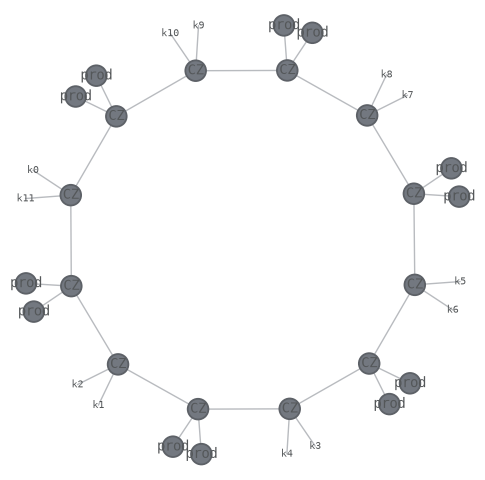

In [18]:
psi.draw()

Looks good. Weird, but good.

## Symmetries
Symmetry of the system is $XK$, where $K$ is complex conjugation.

In [19]:
def multikron(arrays):
    return reduce(np.kron, arrays)

In [20]:
np_X = np.array([
    [0,1],
    [1,0]
])

In [21]:
def get_multisite_qu_X(num_sites):
    np_many_X = multikron([np_X]*num_sites)

    out = qtn.Tensor(
        np_many_X,
        inds=['k', 'b'],
        tags='mulit_site_X',
    )

    return out

## Defect operators

In [22]:
domains_dict = {
    'num_system_sites': 16,
    'symmetry_sites': list(range(4, 12)),
    'left_symmetry_sites': list(range(4, 8)),
    'right_symmetry_sites': list(range(8, 12)),
    'left_defect_sites': [4,5],
    'right_defect_sites': [10,11]
}

In [23]:
symmetry_sites = list(range(5, 19))
left_symmetry_sites = list(range(5,12))
right_symmetry_sites = list(range(12,19))

num_symmetry_sites = len(symmetry_sites)

num_defect_op_sites = 4

num_left_symmetry_non_defect_sites = (
    len(left_symmetry_sites)
    - num_defect_op_sites
)

num_right_symmetry_non_defect_sites = (
    len(right_symmetry_sites)
    - num_defect_op_sites
)

defect_op_dim = 2**num_defect_op_sites

In [24]:
horiztonal_bond_dimension = 16
vertical_bond_dimension = 4

In [25]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [26]:
def get_rho_A(A):
    A_bottom = A.conj().reindex({'kl': 'bl', 'kr': 'br'})
    return A & A_bottom

In [27]:
def rho_A_trace(rho_A):
    out = (
        rho_A
        .reindex({'bl': 'kl', 'br': 'kr'})
        .contract()
    )
    return out

In [28]:
def normalize_A(A):
    rho_A = get_rho_A(A)
    trace = rho_A_trace(rho_A)
    A = A.multiply(trace**(-0.5))

    A_0 = A.tensors[0]
    A_1 = A.tensors[1]
    
    norm_0 = jnp.sqrt(jnp.real((A_0 & A_0.conj()).contract()))
    norm_1 = jnp.sqrt(jnp.real((A_1 & A_1.conj()).contract()))

    A.tensors[0].modify(data=A_0.data*jnp.sqrt(norm_1/norm_0))
    A.tensors[1].modify(data=A_1.data*jnp.sqrt(norm_0/norm_1))

    return A

In [29]:
transpose_reindex_dict = {
    'bl': 'kl',
    'br': 'kr',
    'kl': 'bl',
    'kr': 'br'
}

In [30]:
def rho_A_purity(rho_A):
    tn = (
        (rho_A.reindex(transpose_reindex_dict))
        & rho_A
    )

    out = tn.contract()

    return out

In [31]:
def rho_A_rho_overlap(rho, rho_A):
    tn = (
        (rho_A.reindex(transpose_reindex_dict))
        & rho
    )

    out = tn.contract()

    return out

In [32]:
def loss_func(A, rho, rho_purity):
    rho_A = get_rho_A(A)

    out = np.real(
        rho_purity
        + rho_A_purity(rho_A)
        -2*rho_A_rho_overlap(rho, rho_A)
    )

    return out

In [56]:
def get_tensor_network_factorization(qt_rho, rho_purity, domains_dict):
    # Assuming there is an even number of symmetry sites.
    A_left = qtn.Tensor(
        data=random_uniform_complex((
            vertical_bond_dimension,
            2**(len(domains_dict['left_symmetry_sites'])),
            horiztonal_bond_dimension
        )),
        inds=('vLV', 'kl', 'vH')
    )
    
    A_right = qtn.Tensor(
        data=random_uniform_complex((
            horiztonal_bond_dimension,
            2**(len(domains_dict['right_symmetry_sites'])),
            vertical_bond_dimension
        )),
        inds=('vH', 'kr', 'vRV')
    )

    A = qtn.TensorNetwork([A_left, A_right])

    tnopt = qtn.TNOptimizer(
        A,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="L-BFGS-B",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize(n=100)

    tnopt = qtn.TNOptimizer(
        A_opt,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="adam",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize(n=200)

    return A_opt, tnopt.losses, tnopt.loss_best

In [34]:
def schmidt_decompose_tensor_factorization(A_opt):
    # Left side
    A_l_opt = A_opt.tensors[0]

    tn_l = (
        A_l_opt
        &
        A_l_opt.conj().reindex({'kl': 'bl', 'vH': 'vBH'})
    )
    tn_l = tn_l.contract()

    left_rho_decomp = qtn.tensor_core.tensor_split(
        tn_l,
        left_inds=['kl', 'vH'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vLV'
    )

    diff_l = (
        left_rho_decomp.contract(output_inds=tn_l.inds)
        - tn_l
    )

    left_diff = (diff_l & diff_l.conj()).contract()

    # Right side
    A_r_opt = A_opt.tensors[1]

    tn_r = (
        A_r_opt
        &
        A_r_opt.conj().reindex({'kr': 'br', 'vH': 'vBH'})
    )
    tn_r = tn_r.contract()

    right_rho_decomp = qtn.tensor_core.tensor_split(
        tn_r,
        left_inds=['kr', 'vH'],
        method='svd',
        #cutoff=1e-3,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vRV'
    )

    diff_r = (
        right_rho_decomp.contract(output_inds=tn_r.inds)
        - tn_r
    )

    right_diff = (diff_r & diff_r.conj()).contract()

    out = (
        left_rho_decomp,
        right_rho_decomp,
        left_diff,
        right_diff
    )

    return out

In [35]:
def get_defect_operators(edm, num_iters=20):
    # Assuming edm has indices [kl1, kr2, bl1, br2] each with size 4 (s sites)
    scores = list()

    left_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('bl1'), edm.ind_size('kl1')),
        inds=['kl1', 'bl1'],
        dtype='complex64'
    )

    right_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('br2'), edm.ind_size('kr2')),
        inds=['kr2', 'br2'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (
            (
                edm
                & left_defect_op.reindex({'kl1': 'bl1', 'bl1':'kl1'})
            )
            .contract()
        )
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        right_defect_op = qtn.Tensor(sol, inds = ['kr2', 'br2'])
        
        left_edm = (
            (
                edm
                & right_defect_op.reindex({'kr2': 'br2', 'br2':'kr2'})
            )
            .contract()    
        )
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        left_defect_op = qtn.Tensor(sol, inds = ['kl1', 'bl1'])

    return (left_defect_op, right_defect_op), scores

In [36]:
def get_defect_ops_and_indices_from_density_matrix(qt_rho, domains_dict):
    rho_purification = qtn.tensor_core.tensor_split(
        qt_rho,
        left_inds=['kl', 'kr'],
        method='eigh',
        cutoff=1e-2,
        cutoff_mode='abs',
        absorb=None,
        renorm=False,
        bond_ind='vV'
    )

    purification_diff = rho_purification.contract(output_inds=qt_rho.inds) - qt_rho
    purification_diff_score = (purification_diff & purification_diff.conj()).contract()

    bra_conjugate_rho = (
        rho_purification.tensors[0]
        & rho_purification.tensors[1]
        & (rho_purification.tensors[2].conj())
    )

    left_defect_op_dim = 2**(len(domains_dict['left_defect_sites']))
    right_defect_op_dim = 2**(len(domains_dict['right_defect_sites']))
    left_defect_complement_op_dim = 2**(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    )
    right_defect_complement_op_dim = 2**(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )

    (
        bra_conjugate_rho
        .tensors[0]
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'kr': ['kr1', 'kr2']},
            shape_map={
                'kl': (left_defect_op_dim, left_defect_complement_op_dim),
                'kr': (right_defect_complement_op_dim, right_defect_op_dim)
            }
        )
    )

    (
        bra_conjugate_rho
        .tensors[2]
        .unfuse_(
            unfuse_map={'bl': ['bl1', 'bl2'], 'br': ['br1', 'br2']},
            shape_map={
                'bl': (left_defect_op_dim, left_defect_complement_op_dim),
                'br': (right_defect_complement_op_dim, right_defect_op_dim)
            }
        )
    )

    left_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['left_defect_sites'])
    )
    right_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['right_defect_sites'])
    )
    left_defect_complement_qu_X = get_multisite_qu_X(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    
    )
    right_defect_complement_qu_X = get_multisite_qu_X(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )

    # Effective density matrix
    edm = (
        bra_conjugate_rho.reindex(
            {'bl1': 'bbl1', 'bl2': 'bl2', 'br1': 'br1', 'br2': 'bbr2'}
        )
        & left_defect_qu_X.reindex({'k': 'bl1', 'b': 'bbl1'})
        & left_defect_complement_qu_X.reindex({'k': 'kl2', 'b': 'bl2'})
        & right_defect_complement_qu_X.reindex({'k': 'kr1', 'b': 'br1'})
        & right_defect_qu_X.reindex({'k': 'br2', 'b': 'bbr2'})
    )

    # Ordering of indices important here.
    edm = edm.contract(output_inds=['kl1', 'kr2', 'bl1', 'br2'])

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_defect_l = (
        qt_rho
        .reindex({'kr': 'br'})
        .contract()
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'bl': ['bl1', 'bl2']},
            shape_map={
                'kl': (left_defect_op_dim, left_defect_complement_op_dim),
                'bl': (left_defect_op_dim, left_defect_complement_op_dim)
            }
        )
        .reindex({'kl2': 'bl2'})
        .contract()
    )

    left_defect_op_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & left_defect_qu_X.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & left_defect_qu_X.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_defect_r = (
        qt_rho
        .reindex({'kl': 'bl'})
        .contract()
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2'], 'br': ['br1', 'br2']},
            shape_map={
                'kr': (right_defect_complement_op_dim, right_defect_op_dim),
                'br': (right_defect_complement_op_dim, right_defect_op_dim)
            }
        )
        .reindex({'kr1': 'br1'})
        .contract()
    )

    right_defect_op_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & right_defect_qu_X.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & right_defect_qu_X.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps,
        purification_diff_score
    )

    return out

In [37]:
def get_defect_ops_and_indices_from_factorized_density_matrix(qt_rho,
    left_rho_decomp, right_rho_decomp, domains_dict):

    bra_conjugate_left_rho_decomp = (
        left_rho_decomp.tensors[0]
        & left_rho_decomp.tensors[1]
        & (left_rho_decomp.tensors[2].conj())
    )
    
    bra_conjugate_right_rho_decomp = (
        right_rho_decomp.tensors[0]
        & right_rho_decomp.tensors[1]
        & (right_rho_decomp.tensors[2].conj())
    )

    left_defect_op_dim = 2**(len(domains_dict['left_defect_sites']))
    right_defect_op_dim = 2**(len(domains_dict['right_defect_sites']))
    left_defect_complement_op_dim = 2**(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    )
    right_defect_complement_op_dim = 2**(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )

    (
        bra_conjugate_left_rho_decomp
        .tensors[0]
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2']},
            shape_map={
                'kl': (left_defect_op_dim, left_defect_complement_op_dim)
            }
        )
    )
    
    (
        bra_conjugate_left_rho_decomp
        .tensors[2]
        .unfuse_(
            unfuse_map={'bl': ['bl1', 'bl2']},
            shape_map={
                'bl': (left_defect_op_dim, left_defect_complement_op_dim)
            }
        )
    )
    
    (
        bra_conjugate_right_rho_decomp
        .tensors[0]
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2']},
            shape_map={'kr': (right_defect_complement_op_dim, right_defect_op_dim)}
        )
    )
    
    (
        bra_conjugate_right_rho_decomp
        .tensors[2]
        .unfuse_(
            unfuse_map={'br': ['br1', 'br2']},
            shape_map={'br': (right_defect_complement_op_dim, right_defect_op_dim)}
        )
    )

    left_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['left_defect_sites'])
    )
    right_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['right_defect_sites'])
    )
    left_defect_complement_qu_X = get_multisite_qu_X(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    
    )
    right_defect_complement_qu_X = get_multisite_qu_X(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )
    
    # Effective density matrix
    edm = (
        bra_conjugate_left_rho_decomp.reindex({'bl1': 'bbl1', 'bl2': 'bl2'})
        & left_defect_qu_X.reindex({'k': 'bl1', 'b': 'bbl1'})
        & left_defect_complement_qu_X.reindex({'k': 'kl2', 'b': 'bl2'})
        & right_defect_complement_qu_X.reindex({'k': 'kr1', 'b': 'br1'})
        & right_defect_qu_X.reindex({'k': 'br2', 'b': 'bbr2'})
        & bra_conjugate_right_rho_decomp.reindex({'br1': 'br1', 'br2': 'bbr2'})
    )

    edm = edm.contract(output_inds=['kl1', 'kr2', 'bl1', 'br2'])

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_defect_l = (
        qt_rho
        .reindex({'kr': 'br'})
        .contract()
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'bl': ['bl1', 'bl2']},
            shape_map={
                'kl': (left_defect_op_dim, left_defect_complement_op_dim),
                'bl': (left_defect_op_dim, left_defect_complement_op_dim)
            }
        )
        .reindex({'kl2': 'bl2'})
        .contract()
    )

    left_defect_op_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & left_defect_qu_X.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & left_defect_qu_X.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_defect_r = (
        qt_rho
        .reindex({'kl': 'bl'})
        .contract()
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2'], 'br': ['br1', 'br2']},
            shape_map={
                'kr': (right_defect_complement_op_dim, right_defect_op_dim),
                'br': (right_defect_complement_op_dim, right_defect_op_dim)
            }
        )
        .reindex({'kr1': 'br1'})
        .contract()
    )

    right_defect_op_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & right_defect_qu_X.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & right_defect_qu_X.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl1': 'bl1', 'bl1': 'kl1'})
        & right_defect_operator.reindex({'kr2': 'br2', 'br2': 'kr2'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps
    )

    return out

In [38]:
def get_defect_ops_and_indices_from_restricted_state(psi_restricted, domains_dict):
    psi_0 = psi_restricted

    left_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['left_defect_sites'])
    )
    right_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['right_defect_sites'])
    )
    left_defect_complement_qu_X = get_multisite_qu_X(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    
    )
    right_defect_complement_qu_X = get_multisite_qu_X(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )

    # Effective density matrix
    edm = (
        psi_0
        & left_defect_qu_X.reindex({'k': 'bl1', 'b': 'bbl1'})
        & left_defect_complement_qu_X.reindex({'k': 'kl2', 'b': 'bl2'})
        & right_defect_complement_qu_X.reindex({'k': 'kr1', 'b': 'br1'})
        & right_defect_qu_X.reindex({'k': 'br2', 'b': 'bbr2'})
        & psi_0.reindex({
            'kl1': 'bbl1', 'kl2': 'bl2', 'kr1': 'br1', 'kr2': 'bbr2'
        })
    )

    edm = edm.contract()

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_0 = (
        psi_0
        & psi_0.conj().reindex({'kl1': 'bl1', 'kr2': 'br2'})
    )
    
    rho_0_l = rho_0.reindex({'br2': 'kr2'}).contract()

    left_defect_op_invariant = (
        rho_0_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & left_defect_qu_X.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & left_defect_qu_X.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_0_r = rho_0.reindex({'bl1': 'kl1'}).contract()

    right_defect_op_invariant = (
        rho_0_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & right_defect_qu_X.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & right_defect_qu_X.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl1': 'bl1', 'bl1': 'kl1'})
        & right_defect_operator.reindex({'kr2': 'br2', 'br2': 'kr2'})
    )

    overlap = np.abs(overlap.contract())
    
    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlap
    )

    return out

In [39]:
def get_defect_ops_and_indices_from_restricted_purification_state(
    psi_restricted, domains_dict):
    psi_0 = psi_restricted

    left_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['left_defect_sites'])
    )
    right_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['right_defect_sites'])
    )
    left_defect_complement_qu_X = get_multisite_qu_X(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    
    )
    right_defect_complement_qu_X = get_multisite_qu_X(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )

    # Effective density matrix
    edm = (
        psi_0
        & left_defect_qu_X.reindex({'k': 'bl1', 'b': 'bbl1'})
        & left_defect_complement_qu_X.reindex({'k': 'kl2', 'b': 'bl2'})
        & left_defect_complement_qu_X.reindex({'k': 'kr1', 'b': 'br1'})
        & right_defect_qu_X.reindex({'k': 'br2', 'b': 'bbr2'})
        & psi_0.reindex({
            'kl1': 'bbl1', 'kl2': 'bl2', 'kr1': 'br1', 'kr2': 'bbr2'
        })
    )

    edm = edm.contract()

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_0 = (
        psi_0
        & psi_0.conj().reindex({'kl1': 'bl1', 'kr2': 'br2'})
    )

    rho_0_l = rho_0.reindex({'br2': 'kr2'}).contract()

    left_defect_op_invariant = (
        rho_0_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & left_defect_qu_X.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & left_defect_qu_X.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_0_r = rho_0.reindex({'bl1': 'kl1'}).contract()

    right_defect_op_invariant = (
        rho_0_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & right_defect_qu_X.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & right_defect_qu_X.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    
    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps
    )

    return out

In [40]:
def get_restricted_psis(left_rho_decomp, right_rho_decomp, domains_dict, 
                        cutoff_factor=0.8):
    out = list()

    left_schmidt_vals = left_rho_decomp.tensors[1].data
    right_schmidt_vals = right_rho_decomp.tensors[1].data

    left_defect_op_dim = 2**(len(domains_dict['left_defect_sites']))
    right_defect_op_dim = 2**(len(domains_dict['right_defect_sites']))
    left_defect_complement_op_dim = 2**(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    )
    right_defect_complement_op_dim = 2**(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )
    
    for i, sl in enumerate(left_schmidt_vals):
        if sl >= cutoff_factor*max(left_schmidt_vals):
            left_psi = left_rho_decomp.tensors[0].isel({'vLV': i})
            for j, sr in enumerate(right_schmidt_vals):
                if sr >= cutoff_factor*max(right_schmidt_vals):
                    right_psi = right_rho_decomp.tensors[0].isel({'vRV': j})

                    psi = left_psi & right_psi
                    psi_norm = (psi & psi.conj()).contract()

                    (
                        psi
                        .multiply(
                            psi_norm**(-0.5),
                            inplace=True,
                            spread_over=2
                        )
                    )

                    (
                        psi
                        .tensors[0]
                        .unfuse_(
                            unfuse_map={'kl': ['kl1', 'kl2']},
                            shape_map={
                                'kl': (left_defect_op_dim, left_defect_complement_op_dim)
                            }
                        )
                    )

                    (
                        psi
                        .tensors[1]
                        .unfuse_(
                            unfuse_map={'kr': ['kr1', 'kr2']},
                            shape_map={
                                'kr': (right_defect_complement_op_dim, right_defect_op_dim)
                            }
                        )
                    )

                    out.append([psi, sl, sr])

    return out

In [41]:
def get_restricted_psis_from_purification(qt_rho, domains_dict,
                                          cutoff_factor=0.65):
    out = list()

    rho_purification = qtn.tensor_core.tensor_split(
        qt_rho,
        left_inds=['kl', 'kr'],
        method='eigh',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    purification_diff = rho_purification.contract(output_inds=qt_rho.inds) - qt_rho
    purification_diff_score = (purification_diff & purification_diff.conj()).contract()

    schmidt_vals = rho_purification.tensors[1].data

    left_defect_op_dim = 2**(len(domains_dict['left_defect_sites']))
    right_defect_op_dim = 2**(len(domains_dict['right_defect_sites']))
    left_defect_complement_op_dim = 2**(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    )
    right_defect_complement_op_dim = 2**(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )

    for i, schmidt_val in enumerate(schmidt_vals):
        if schmidt_val >= cutoff_factor*max(schmidt_vals):
            psi = rho_purification.tensors[0].isel({'vV': i})
            psi_norm = (psi & psi.conj()).contract()

            psi = psi_norm**(-0.5)*psi

            (
                psi
                .unfuse_(
                    unfuse_map={'kl': ['kl1', 'kl2'], 'kr': ['kr1', 'kr2']},
                    shape_map={
                        'kl': (left_defect_op_dim, left_defect_complement_op_dim),
                        'kr': (right_defect_complement_op_dim, right_defect_op_dim)
                    }
                )
            )

            out.append([psi, schmidt_val])

    return (out, purification_diff_score)

In [42]:
def get_left_right_defect_regions_schmidt_vals(qt_rho, domains_dict):
    unfuse_map = {
        'kl': ['kl1', 'kl2'],
        'kr': ['kr1', 'kr2'],
        'bl': ['bl1', 'bl2'],
        'br': ['br1', 'br2']
    }

    left_defect_op_dim = 2**(len(domains_dict['left_defect_sites']))
    right_defect_op_dim = 2**(len(domains_dict['right_defect_sites']))
    left_defect_complement_op_dim = 2**(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    )
    right_defect_complement_op_dim = 2**(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )
    
    shape_map = {
        'kl': (left_defect_op_dim, left_defect_complement_op_dim),
        'kr': (right_defect_complement_op_dim, right_defect_op_dim),
        'bl': (left_defect_op_dim, left_defect_complement_op_dim),
        'br': (right_defect_complement_op_dim, right_defect_op_dim)
    }

    rho = (
        qt_rho
        .unfuse(unfuse_map=unfuse_map, shape_map=shape_map)
    )

    rho = rho.reindex({'kl2': 'bl2', 'kr1': 'br1'})
    rho = rho.contract()

    rho_left_right_split = qtn.tensor_core.tensor_split(
        rho,
        left_inds=['kl1', 'bl1'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    rho_left_right_schmidt_vals = rho_left_right_split.tensors[1].data

    return rho_left_right_schmidt_vals

In [43]:
def get_rdm_from_quimb_psi(psi, symmetry_sites):
    rho = qtn.TensorNetwork(
        [psi, psi.conj().reindex({f'k{i}': f'b{i}' for i in symmetry_sites})],
        virtual=True
    )

    rho.contract(inplace=True)

    return rho

In [44]:
def get_purity_from_quimb_rdm(rdm):
    rdm_indices = rdm.outer_inds()

    k_indices = [s for s in rdm_indices if s.startswith('k')]
    b_indices = [s for s in rdm_indices if s.startswith('b')]

    rdm_transpose_map = {
        **{s: f'b{s[1:]}' for s in k_indices},
        **{s: f'k{s[1:]}' for s in b_indices}
    }

    out = (
        rdm
        & rdm.reindex(rdm_transpose_map)
    )
    out.contract(inplace=True)
    out = np.real(out.item())

    return out

In [45]:
def extract_time_reversal_information(psi, domains_dict):
    # Assume psi is a quimb tensor/tensor network with indices for each site.
    rho = get_rdm_from_quimb_psi(psi, domains_dict['symmetry_sites'])
    
    rho_purity = get_purity_from_quimb_rdm(rho)
    
    # Hardcode warning
    qt_rho = (
        rho
        .tensors[0]
        .fuse({
            'kl': [f'k{i}' for i in domains_dict['left_symmetry_sites']],
            'kr': [f'k{i}' for i in domains_dict['right_symmetry_sites']],
            'bl': [f'b{i}' for i in domains_dict['left_symmetry_sites']],
            'br': [f'b{i}' for i in domains_dict['right_symmetry_sites']]
        })
    )

    qt_rho_left_right_schmidt_vals = (
        get_left_right_defect_regions_schmidt_vals(qt_rho, domains_dict)
    )

    rho_out = get_defect_ops_and_indices_from_density_matrix(qt_rho, domains_dict)

    pair = get_restricted_psis_from_purification(qt_rho, domains_dict)
    purification_restricted_psi_pairs, purification_diff_score = pair

    purification_restricted_psi_output = list()
    for psi_0, sv in purification_restricted_psi_pairs:
        purification_restricted_psi_output.append(
            [
                sv,
                *get_defect_ops_and_indices_from_restricted_purification_state(
                    psi_0,
                    domains_dict
                )
            ]
        )
    
    A_opt, A_losses, A_opt_best_loss = get_tensor_network_factorization(
        qt_rho,
        rho_purity,
        domains_dict
    )

    schmidt_decomp_out = schmidt_decompose_tensor_factorization(A_opt)
    
    (
        left_rho_decomp,
        right_rho_decomp,
        left_diff,
        right_diff
    ) = schmidt_decomp_out

    rho_defect_out = get_defect_ops_and_indices_from_factorized_density_matrix(
        qt_rho,
        left_rho_decomp,
        right_rho_decomp,
        domains_dict
    )

    (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps
    ) = rho_defect_out

    restricted_psi_triples = get_restricted_psis(
        left_rho_decomp,
        right_rho_decomp,
        domains_dict
    )

    restricted_psi_output = list()
    for psi_0, sl, sr in restricted_psi_triples:
        restricted_psi_output.append(
            [
                sl, sr,
                *get_defect_ops_and_indices_from_restricted_state(
                    psi_0, domains_dict
                )
            ]
        )

    out = (
        qt_rho_left_right_schmidt_vals,
        rho_out,
        purification_diff_score,
        purification_restricted_psi_output,
        A_losses,
        A_opt_best_loss,
        left_diff,
        right_diff,
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps,
        restricted_psi_output
    )

    return out

In [46]:
def extract_factorization_time_reversal_information(psi, domains_dict):
    # Assume psi is a quimb tensor/tensor network with indices for each site.
    rho = get_rdm_from_quimb_psi(psi, domains_dict['symmetry_sites'])
    
    rho_purity = get_purity_from_quimb_rdm(rho)
    
    # Hardcode warning
    qt_rho = (
        rho
        .tensors[0]
        .fuse({
            'kl': [f'k{i}' for i in domains_dict['left_symmetry_sites']],
            'kr': [f'k{i}' for i in domains_dict['right_symmetry_sites']],
            'bl': [f'b{i}' for i in domains_dict['left_symmetry_sites']],
            'br': [f'b{i}' for i in domains_dict['right_symmetry_sites']]
        })
    )

    qt_rho_left_right_schmidt_vals = (
        get_left_right_defect_regions_schmidt_vals(qt_rho, domains_dict)
    )
    
    A_opt, A_losses, A_opt_best_loss = get_tensor_network_factorization(
        qt_rho,
        rho_purity,
        domains_dict
    )

    schmidt_decomp_out = schmidt_decompose_tensor_factorization(A_opt)
    
    (
        left_rho_decomp,
        right_rho_decomp,
        left_diff,
        right_diff
    ) = schmidt_decomp_out

    rho_defect_out = get_defect_ops_and_indices_from_factorized_density_matrix(
        qt_rho,
        left_rho_decomp,
        right_rho_decomp,
        domains_dict
    )

    (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps
    ) = rho_defect_out

    restricted_psi_triples = get_restricted_psis(
        left_rho_decomp,
        right_rho_decomp,
        domains_dict
    )

    restricted_psi_output = list()
    for psi_0, sl, sr in restricted_psi_triples:
        restricted_psi_output.append(
            [
                sl, sr,
                *get_defect_ops_and_indices_from_restricted_state(
                    psi_0, domains_dict
                )
            ]
        )

    out = (
        qt_rho_left_right_schmidt_vals,
        A_losses,
        A_opt_best_loss,
        left_diff,
        right_diff,
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps,
        restricted_psi_output
    )

    return out

## Apply random unitary to groundstate

In [47]:
# Hard code warning
def generate_random_symmetry_respecting_unitary():
    o = ortho_group.rvs(4)

    np_H = np.pow(2, -1/2)*np.array([
        [1,1],
        [1,-1]
    ])

    np_W = np.kron(np_H, np_H) @ np.diag([1, 1j, 1j, 1])

    u = np_W @ o @ (np_W.conj().T)

    return u

In [48]:
# Warning, likely making assupmtions about shape of psi, number of sites being even here etc.
def apply_haar_random_fdlu_to_quimb_state(psi, domains_dict):
    num_sites = domains_dict['num_system_sites']

    depth = domains_dict['fdlu_depth']
    offset = domains_dict['fdlu_offset']

    all_circuit_lists = [
        list() for _ in range(depth)
    ]

    for layer, circuit_list in enumerate(all_circuit_lists):
        delta = layer
    
        for i in range(num_sites//2):
            site_1 = ((2*i)+delta+offset)%num_sites
            site_2 = ((2*i)+1+delta+offset)%num_sites

            u = generate_random_symmetry_respecting_unitary()

            inds=[
                f'k_{layer+1}_{site_1}',
                f'k_{layer+1}_{site_2}',
                f'k_{layer}_{site_1}',
                f'k_{layer}_{site_2}'
            ]
            
            qu_u = qtn.Tensor(
                u.reshape((2,)*4),
                inds=inds,
                tags=f'Layer_{layer}'
            )

            circuit_list.append(qu_u)

    all_tensors = (
        [psi.reindex({f'k{i}': f'k_0_{i}' for i in range(num_sites)})]
        + sum(all_circuit_lists, start=[])
    )

    out = (
        qtn
        .TensorNetwork(all_tensors, virtual=False)
        .mangle_inner_()
        .reindex({f'k_{depth}_{i}': f'k{i}' for i in range(num_sites)}) 
    )

    return out

In [49]:
def extract_time_reversal_information_after_random_fdlu(psi, domains_dict,
    num_random_states=20):

    out = list()

    for _ in range(num_random_states):
        rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)
        out.append(extract_time_reversal_information(rand_psi, domains_dict))

    return out

In [50]:
def extract_factorization_time_reversal_information_after_random_fdlu(psi,
    domains_dict, num_random_states=20):
    out = list()

    for _ in range(num_random_states):
        rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)
        data = extract_factorization_time_reversal_information(
            rand_psi,
            domains_dict
        )
        out.append(data)

    return out

In [51]:
def get_quimb_psi_from_quspin_psi(quspin_psi):
    quimb_psi = qtn.Tensor(
        quspin_psi[::-1].reshape((2,)*num_sites),
        inds=[f'k{i}' for i in range(num_sites)]
    )

    return quimb_psi

# MPS comparison test
Delete later

In [52]:
domains_dict = {
    'num_system_sites': 16,
    'symmetry_sites': list(range(4, 12)),
    'left_symmetry_sites': list(range(4, 8)),
    'right_symmetry_sites': list(range(8, 12)),
    'left_defect_sites': [4,5],
    'right_defect_sites': [10,11],
    'fdlu_depth': 2,
    'fdlu_offset': 0
}

In [53]:
cluster_psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [57]:
out = extract_factorization_time_reversal_information(cluster_psi, domains_dict)

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from complex64 to complex128.
  warnings.warn(


In [60]:
out[5]

array([2.49708788e-01, 4.94307927e-05, 3.39450896e-05, 2.86096216e-05,
       2.66460804e-05, 2.01256292e-05, 1.80054705e-05, 1.53232997e-05,
       1.25688990e-05, 9.68586409e-06, 7.71346309e-06, 7.61497892e-06,
       5.53787331e-06, 4.51958107e-06, 1.17855976e-06, 7.63209711e-07])

In [61]:
out[8]

[np.float64(1.133645146615659),
 np.float64(0.9988349510839629),
 np.float64(0.998834960766722),
 np.float64(0.9988349607667222),
 np.float64(0.9988349607667221),
 np.float64(0.9988349607667227),
 np.float64(0.9988349607667225),
 np.float64(0.9988349607667222),
 np.float64(0.9988349607667224),
 np.float64(0.998834960766722),
 np.float64(0.9988349607667217),
 np.float64(0.9988349607667221),
 np.float64(0.9988349607667222),
 np.float64(0.9988349607667225),
 np.float64(0.9988349607667221),
 np.float64(0.9988349607667227),
 np.float64(0.9988349607667222),
 np.float64(0.9988349607667217),
 np.float64(0.9988349607667221),
 np.float64(0.9988349607667223),
 np.float64(0.9988349607667221),
 np.float64(0.9988349607667224),
 np.float64(0.9988349607667215),
 np.float64(0.9988349607667222),
 np.float64(0.9988349607667223),
 np.float64(0.9988349607667216),
 np.float64(0.998834960766722),
 np.float64(0.998834960766723),
 np.float64(0.9988349607667226),
 np.float64(0.9988349607667222),
 np.float64(0.9

# Profile

In [52]:
def extract_factorization_time_reversal_information_profile(psi, domains_dict):
    times = list()
    time_names = list()
    
    time_names.append("Get rho")
    times.append(time())
    rho = get_rdm_from_quimb_psi(psi, domains_dict['symmetry_sites'])
    
    
    time_names.append("Get purity")
    times.append(time())
    rho_purity = get_purity_from_quimb_rdm(rho)
    
    time_names.append("Reshape rho")
    times.append(time())
    # Hardcode warning
    qt_rho = (
        rho
        .tensors[0]
        .fuse({
            'kl': [f'k{i}' for i in domains_dict['left_symmetry_sites']],
            'kr': [f'k{i}' for i in domains_dict['right_symmetry_sites']],
            'bl': [f'b{i}' for i in domains_dict['left_symmetry_sites']],
            'br': [f'b{i}' for i in domains_dict['right_symmetry_sites']]
        })
    )
    
    time_names.append("Get left right rho schmidt vals")
    times.append(time())
    qt_rho_left_right_schmidt_vals = (
        get_left_right_defect_regions_schmidt_vals(qt_rho, domains_dict)
    )
    
    time_names.append("Get tensor network factorization")
    times.append(time())
    A_opt, A_losses, A_opt_best_loss = get_tensor_network_factorization(
        qt_rho,
        rho_purity,
        domains_dict
    )
    
    time_names.append("Schmidt decompose tensor factorization")
    times.append(time())
    schmidt_decomp_out = schmidt_decompose_tensor_factorization(A_opt)
    
    (
        left_rho_decomp,
        right_rho_decomp,
        left_diff,
        right_diff
    ) = schmidt_decomp_out
    
    time_names.append("Get defect ops and indices from factorized rho")
    times.append(time())
    rho_defect_out = get_defect_ops_and_indices_from_factorized_density_matrix(
        qt_rho,
        left_rho_decomp,
        right_rho_decomp,
        domains_dict
    )
    
    (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps
    ) = rho_defect_out
    
    time_names.append("Get schmidt states")
    times.append(time())
    restricted_psi_triples = get_restricted_psis(
        left_rho_decomp,
        right_rho_decomp,
        domains_dict
    )
    
    time_names.append("Get defect ops and indices from schmidt states")
    times.append(time())
    restricted_psi_output = list()
    for psi_0, sl, sr in restricted_psi_triples:
        restricted_psi_output.append(
            [
                sl, sr,
                *get_defect_ops_and_indices_from_restricted_state(
                    psi_0, domains_dict
                )
            ]
        )
    
    times.append(time())
    out = (
        qt_rho_left_right_schmidt_vals,
        A_losses,
        A_opt_best_loss,
        left_diff,
        right_diff,
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps,
        restricted_psi_output
    )
    
    times = np.array(times)
    delta_times_array = times[1:]-times[:-1]
    delta_times_dict = {
        n: t.item() for n, t in zip(time_names, delta_times_array)
    }

    return out, delta_times_dict

In [53]:
def get_average(l):
    return sum(l)/(len(l))

In [54]:
def extract_factorization_time_reversal_information_profile_multiple_runs(
    domains_dict, num_runs=10, print_tqdm=False):

    to_loop = tqdm(range(num_runs)) if print_tqdm else range(num_runs)

    psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

    out_list = list()
    times_list = list()
    for _ in to_loop:
        rand_psi = apply_haar_random_fdlu_to_quimb_state(
            psi,
            domains_dict
        )
        out, times_dict = extract_factorization_time_reversal_information_profile(
            rand_psi,
            domains_dict
        )
        out_list.append(out)
        times_list.append(times_dict)

    ave_time_dict = {
        k: get_average([d[k] for d in times_list])
        for k in times_list[0].keys()
    }

    return out_list, ave_time_dict

## Run 1

In [55]:
domains_dict = {
    'num_system_sites': 16,
    'symmetry_sites': list(range(4, 12)),
    'left_symmetry_sites': list(range(4, 8)),
    'right_symmetry_sites': list(range(8, 12)),
    'left_defect_sites': [4,5],
    'right_defect_sites': [10,11],
    'fdlu_depth': 2,
    'fdlu_offset': 0
}

In [56]:
cluster_psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [57]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(
    cluster_psi,
    domains_dict
)

In [58]:
out, times_dict = extract_factorization_time_reversal_information_profile_multiple_runs(
    domains_dict,
    num_runs=5,
    print_tqdm=True
)

  0%|                                                                                                                                         | 0/5 [00:00<?, ?it/s]/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from complex64 to complex128.
  warnings.warn(
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:10<00:00,  2.02s/it]


In [59]:
times_dict

{'Get rho': 0.02257685661315918,
 'Get purity': 0.0038108348846435545,
 'Reshape rho': 0.0017056941986083984,
 'Get left right rho schmidt vals': 0.010192346572875977,
 'Get tensor network factorization': 1.318082618713379,
 'Schmidt decompose tensor factorization': 0.4657119274139404,
 'Get defect ops and indices from factorized rho': 0.0738828182220459,
 'Get schmidt states': 0.03367018699645996,
 'Get defect ops and indices from schmidt states': 0.09057297706604003}

## Run 2

In [60]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(5, 15)),
    'left_symmetry_sites': list(range(5, 10)),
    'right_symmetry_sites': list(range(10, 15)),
    'left_defect_sites': [5,6],
    'right_defect_sites': [13,14],
    'fdlu_depth': 2,
    'fdlu_offset': 0
}

In [61]:
depth=2
offset=0

In [62]:
psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [65]:
out, times_dict = extract_factorization_time_reversal_information_profile_multiple_runs(
    domains_dict,
    num_runs=5,
    print_tqdm=True
)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:19<00:00,  3.85s/it]


In [66]:
times_dict

{'Get rho': 0.024242305755615236,
 'Get purity': 0.03444585800170898,
 'Reshape rho': 0.008323192596435547,
 'Get left right rho schmidt vals': 0.0006259918212890625,
 'Get tensor network factorization': 1.9803680419921874,
 'Schmidt decompose tensor factorization': 1.5579933643341064,
 'Get defect ops and indices from factorized rho': 0.05986566543579101,
 'Get schmidt states': 0.10242609977722168,
 'Get defect ops and indices from schmidt states': 0.07918119430541992}

## Run 3

In [71]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(5, 15)),
    'left_symmetry_sites': list(range(5, 10)),
    'right_symmetry_sites': list(range(10, 15)),
    'left_defect_sites': [5,6,7],
    'right_defect_sites': [12,13,14],
    'fdlu_depth': 2,
    'fdlu_offset': 0
}

In [73]:
psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [74]:
out, times_dict = extract_factorization_time_reversal_information_profile_multiple_runs(
    domains_dict,
    num_runs=5,
    print_tqdm=True
)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:17<00:00,  3.49s/it]


In [75]:
times_dict

{'Get rho': 0.023705387115478517,
 'Get purity': 0.034911298751831056,
 'Reshape rho': 0.008163261413574218,
 'Get left right rho schmidt vals': 0.013292169570922852,
 'Get tensor network factorization': 1.854941987991333,
 'Schmidt decompose tensor factorization': 0.35887889862060546,
 'Get defect ops and indices from factorized rho': 0.15327677726745606,
 'Get schmidt states': 0.08735718727111816,
 'Get defect ops and indices from schmidt states': 0.9431786060333252}

## Run 4

In [76]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(5, 15)),
    'left_symmetry_sites': list(range(5, 10)),
    'right_symmetry_sites': list(range(10, 15)),
    'left_defect_sites': [5,6,7,8],
    'right_defect_sites': [11,12,13,14],
    'fdlu_depth': 2,
    'fdlu_offset': 0
}

In [79]:
out, times_dict = extract_factorization_time_reversal_information_profile_multiple_runs(
    domains_dict,
    num_runs=5,
    print_tqdm=True
)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:37<00:00,  7.44s/it]


In [80]:
times_dict

{'Get rho': 0.020371294021606444,
 'Get purity': 0.03417582511901855,
 'Reshape rho': 0.008192729949951173,
 'Get left right rho schmidt vals': 0.2913003921508789,
 'Get tensor network factorization': 1.8500779628753663,
 'Schmidt decompose tensor factorization': 1.1418935298919677,
 'Get defect ops and indices from factorized rho': 0.46033177375793455,
 'Get schmidt states': 0.09273037910461426,
 'Get defect ops and indices from schmidt states': 3.526845932006836}

## Run 5

In [84]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(5, 16)),
    'left_symmetry_sites': list(range(5, 10)),
    'right_symmetry_sites': list(range(10, 16)),
    'left_defect_sites': [5,6,7,8],
    'right_defect_sites': [12,13,14, 15],
    'fdlu_depth': 2,
    'fdlu_offset': 0
}

In [82]:
out, times_dict = extract_factorization_time_reversal_information_profile_multiple_runs(
    domains_dict,
    num_runs=5,
    print_tqdm=True
)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [01:22<00:00, 16.59s/it]


In [85]:
psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [86]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(
    psi,
    domains_dict
)

In [87]:
rho = get_rdm_from_quimb_psi(psi, domains_dict['symmetry_sites'])

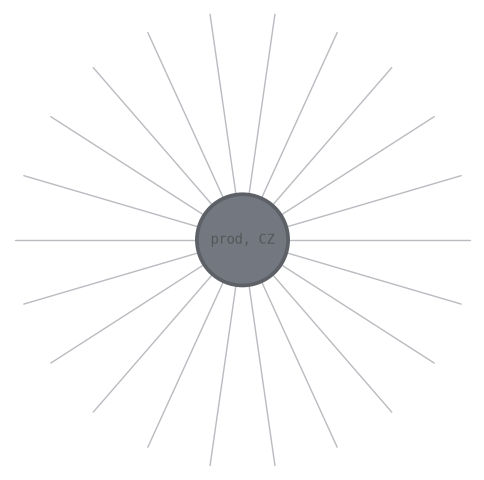

In [88]:
rho.draw()

In [95]:
from humanize import naturalsize

In [96]:
naturalsize(rho.tensors[0].data.nbytes)

'33.6 MB'

In [83]:
times_dict

{'Get rho': 0.07013330459594727,
 'Get purity': 0.2176060199737549,
 'Reshape rho': 0.026119375228881837,
 'Get left right rho schmidt vals': 0.08807501792907715,
 'Get tensor network factorization': 13.486898040771484,
 'Schmidt decompose tensor factorization': 0.6550490856170654,
 'Get defect ops and indices from factorized rho': 0.2922663688659668,
 'Get schmidt states': 0.20807914733886718,
 'Get defect ops and indices from schmidt states': 1.5285733699798585}

# Test runs

## Round 1 - Depth 2, offset 0

In [53]:
domains_dict = {
    'num_system_sites': 16,
    'symmetry_sites': list(range(4, 12)),
    'left_symmetry_sites': list(range(4, 8)),
    'right_symmetry_sites': list(range(8, 12)),
    'left_defect_sites': [4,5],
    'right_defect_sites': [10,11]
}

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [54]:
depth=2
offset=0

In [55]:
psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [56]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)

In [57]:
test_out = extract_factorization_time_reversal_information(
    rand_psi,
    domains_dict
)

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from complex64 to complex128.
  warnings.warn(


In [58]:
test_out[0]

array([0.25      , 0.04099926, 0.00484835])

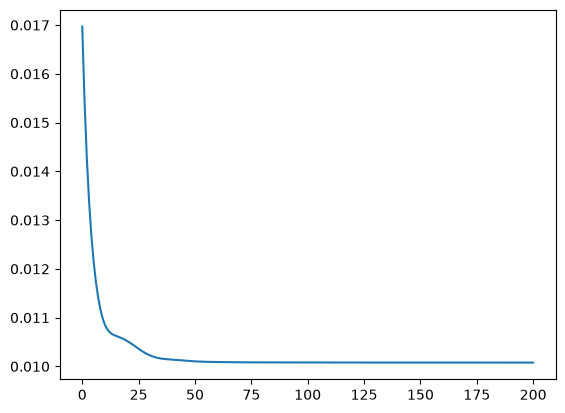

In [60]:
plt.plot(test_out[1])

In [61]:
test_out[3]

np.complex64(8.7945883e-13+0j)

In [62]:
test_out[4]

np.complex64(9.798982e-13+0j)

In [63]:
test_out[5]

array([2.50331132e-02, 1.10579760e-02, 9.09329859e-03, 5.42402160e-03,
       3.07118291e-03, 3.06218489e-03, 1.38526636e-03, 2.74730742e-04,
       1.43265152e-04, 5.67986031e-05, 5.60815808e-05, 4.48456223e-05,
       4.13723366e-05, 2.88817936e-05, 1.67455195e-05, 7.61481848e-06])

In [65]:
test_out[6], test_out[7] 

(np.complex128(0.9999999999999214+3.469446951953614e-17j),
 np.complex128(0.9999999999999758+1.3877787807814457e-17j))

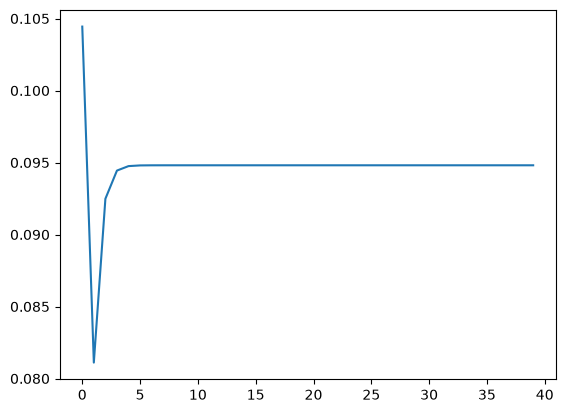

In [67]:
plt.plot(test_out[8])

These are bad...

In [68]:
test_out[9]

[[np.float32(0.5842763),
  np.float32(0.5725414),
  array([1.88932177e-01, 1.73788565e-01, 6.87473217e-02, 6.66424864e-02,
         2.70885169e-02, 1.46970391e-02, 4.03748533e-03, 2.74699916e-03,
         3.53564515e-04, 2.22264598e-04, 1.72101350e-04, 1.70916466e-04,
         1.14956141e-04, 8.56504352e-05, 1.90196332e-05, 8.39343255e-06]),
  np.complex128(1.0000002384185793+0j),
  np.complex128(1.0000002831220631+6.053596679489459e-09j),
  np.float64(0.6643365415615232)],
 [np.float32(0.5842763),
  np.float32(0.5630212),
  array([2.29603545e-01, 2.18839483e-01, 5.99220158e-02, 4.77539912e-02,
         1.50753043e-02, 1.15436767e-02, 5.18124035e-03, 2.72373560e-03,
         6.35625376e-04, 2.80179119e-04, 2.28200270e-04, 1.05726312e-04,
         9.53328576e-05, 4.60218332e-05, 2.92734927e-05, 1.39285631e-05]),
  np.complex128(1.0000000745058066+5.551115123125783e-17j),
  np.complex128(1.0000001005828394-7.217749897758807e-09j),
  np.float64(0.6683657207012395)],
 [np.float32(0.5842763

## Round 2 - Depth 2, offset 0, 20 sites

In [69]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(5, 15)),
    'left_symmetry_sites': list(range(5, 10)),
    'right_symmetry_sites': list(range(10, 15)),
    'left_defect_sites': [5,6],
    'right_defect_sites': [13,14]
}

In [70]:
depth=2
offset=0

In [71]:
psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [72]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)

In [73]:
test_out = extract_factorization_time_reversal_information(
    rand_psi,
    domains_dict
)

In [74]:
test_out[0]

array([0.25])

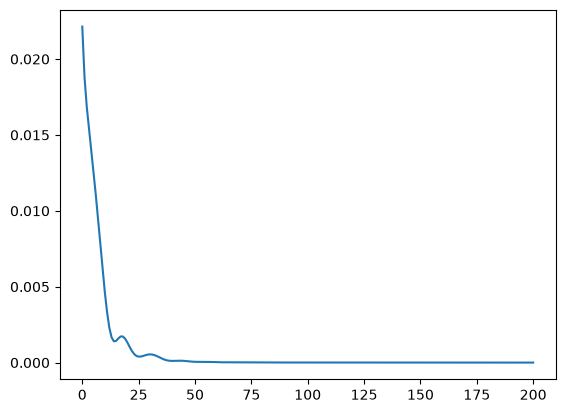

In [75]:
plt.plot(test_out[1])

In [76]:
test_out[1][-1]

1.1473894119262695e-06

In [77]:
test_out[3]

np.complex64(2.492167e-12+0j)

In [78]:
test_out[4]

np.complex64(9.417632e-13+0j)

In [79]:
test_out[5]

array([4.42155767e-02, 1.81504132e-04, 1.04329215e-04, 5.96694376e-05,
       4.18474947e-05, 3.01985453e-05, 2.89905988e-05, 2.74655297e-05,
       2.06246815e-05, 1.72050438e-05, 1.33599253e-05, 9.82376775e-06,
       5.80694836e-06, 5.52526951e-06, 3.29879099e-06, 1.52973631e-06])

In [80]:
test_out[6], test_out[7] 

(np.complex128(-1.0000000000000042+0j),
 np.complex128(-0.9999999999996354+5.551115123125783e-17j))

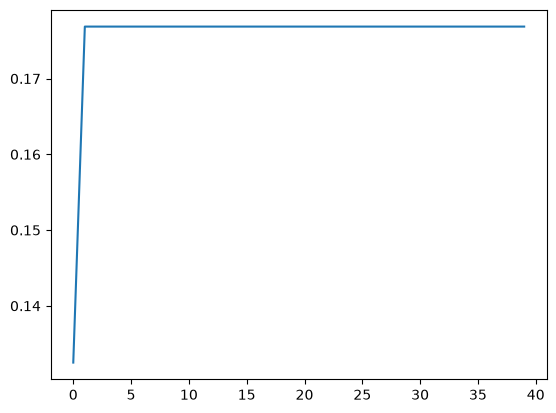

In [81]:
plt.plot(test_out[8])

In [82]:
test_out[9]

[[np.float32(0.88194793),
  np.float32(0.49796277),
  array([1.28424424e-01, 4.09786143e-04, 1.26626731e-04, 1.10497375e-04,
         7.65592970e-05, 5.59978560e-05, 4.29789067e-05, 3.95176420e-05,
         3.32762504e-05, 2.13640895e-05, 2.02899485e-05, 1.64963554e-05,
         1.06991301e-05, 1.05339441e-05, 5.12500678e-06, 2.21605573e-06]),
  np.complex128(-0.9999997615814207+1.1175870895385742e-08j),
  np.complex128(-0.99999974668026-1.3344106736257189e-08j),
  np.float64(0.513697327169772)],
 [np.float32(0.88194793),
  np.float32(0.48368385),
  array([1.44933367e-01, 1.61759375e-04, 1.12087099e-04, 1.02789167e-04,
         6.84233216e-05, 6.63798364e-05, 5.43677250e-05, 4.76944781e-05,
         3.50973884e-05, 2.75962681e-05, 2.50043235e-05, 1.82876144e-05,
         1.57658082e-05, 1.21150987e-05, 4.71849777e-06, 2.17475844e-07]),
  np.complex128(-1.0000000149011612-1.3969838619232178e-08j),
  np.complex128(-1.0000000894069674+3.958121108649237e-09j),
  np.float64(0.57973339248917

## Round 3 - Depth 2, offset 0, 20 sites, 3 defect sites

In [83]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(5, 15)),
    'left_symmetry_sites': list(range(5, 10)),
    'right_symmetry_sites': list(range(10, 15)),
    'left_defect_sites': [5,6,7],
    'right_defect_sites': [12,13,14]
}

In [84]:
depth=2
offset=0

In [85]:
psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [86]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)

In [87]:
test_out = extract_factorization_time_reversal_information(
    rand_psi,
    domains_dict
)

In [88]:
test_out[0]

array([0.17214696, 0.05182075])

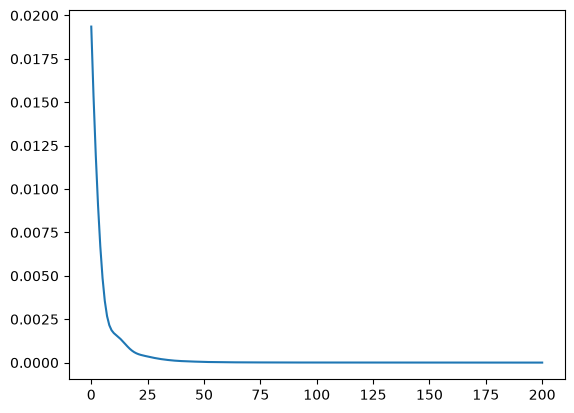

In [89]:
plt.plot(test_out[1])

In [90]:
test_out[1][-1]

8.195638656616211e-07

In [91]:
test_out[3]

np.complex64(2.681272e-12+0j)

In [92]:
test_out[4]

np.complex64(2.7949446e-12+0j)

In [93]:
test_out[5]

array([2.34124799e-02, 2.16154602e-02, 6.56703302e-03, 5.63502585e-03,
       3.85662708e-03, 2.09781380e-03, 1.26068577e-03, 1.15205369e-03,
       6.62399176e-04, 5.34251778e-04, 3.10954077e-04, 2.38901423e-04,
       2.00744212e-04, 1.88997422e-04, 1.48297906e-04, 1.32979205e-04,
       7.56498083e-05, 6.94228677e-05, 6.70219533e-05, 6.24765907e-05,
       6.17426165e-05, 5.17519264e-05, 4.67832494e-05, 4.38790306e-05,
       4.16826635e-05, 4.11151569e-05, 3.91035936e-05, 3.64163651e-05,
       3.27356670e-05, 3.24861157e-05, 2.98927001e-05, 2.69901400e-05,
       2.44053057e-05, 2.40282949e-05, 2.23875380e-05, 2.08602484e-05,
       1.89009283e-05, 1.79834177e-05, 1.65932822e-05, 1.57542967e-05,
       1.50075965e-05, 1.45146237e-05, 1.14782856e-05, 1.13622576e-05,
       1.07275053e-05, 1.04743545e-05, 9.27631269e-06, 8.13621731e-06,
       6.82680375e-06, 6.42334295e-06, 5.66425700e-06, 5.53108071e-06,
       5.43018109e-06, 4.52877215e-06, 4.47718742e-06, 3.27154415e-06,
      

In [94]:
test_out[6], test_out[7] 

(np.complex128(-0.9999999999998808+1.3877787807814457e-17j),
 np.complex128(-0.9999999999997482+9.08794293014159e-08j))

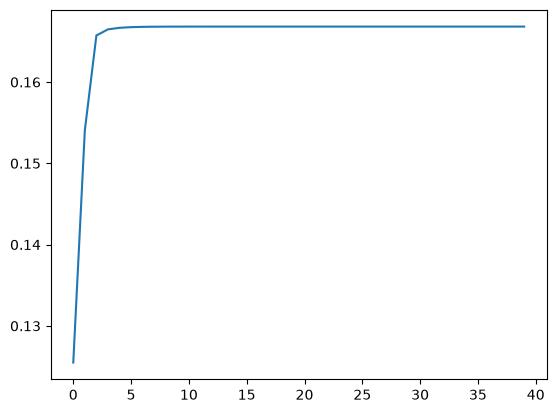

In [95]:
plt.plot(test_out[8])

In [96]:
test_out[9]

[[np.float32(0.990532),
  np.float32(0.9731059),
  array([8.73141131e-02, 7.66853960e-02, 2.99177497e-03, 1.95829029e-03,
         1.46370058e-03, 1.03967555e-03, 1.03483759e-03, 7.33997095e-04,
         3.79338158e-04, 2.63623191e-04, 2.33275034e-04, 1.99039479e-04,
         1.77141864e-04, 1.25435356e-04, 1.21335327e-04, 1.05997185e-04,
         1.03647607e-04, 8.11464902e-05, 7.48754877e-05, 6.80787479e-05,
         6.46873875e-05, 5.55056940e-05, 4.49821393e-05, 4.25332576e-05,
         4.01093981e-05, 3.53673923e-05, 3.06560996e-05, 2.30629260e-05,
         2.11308010e-05, 1.85768834e-05, 1.54312733e-05, 1.37600417e-05,
         1.33127485e-05, 1.15615103e-05, 8.25574205e-06, 7.28133475e-06,
         7.02683356e-06, 6.92804019e-06, 5.51395642e-06, 5.02554964e-06,
         3.91933387e-06, 3.81284772e-06, 3.29560902e-06, 2.65059340e-06,
         2.41281541e-06, 2.22549239e-06, 2.00285097e-06, 1.46905922e-06,
         1.19612351e-06, 1.04250308e-06, 7.77592809e-07, 6.02490520e-07,
  

## Round 4 - Depth 2, offset 0, 20 sites, 4 defect sites, 2 site separation

In [102]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(5, 15)),
    'left_symmetry_sites': list(range(5, 10)),
    'right_symmetry_sites': list(range(10, 15)),
    'left_defect_sites': [5,6,7,8],
    'right_defect_sites': [11,12,13,14]
}

In [103]:
depth=2
offset=0

In [104]:
psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [105]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)

In [106]:
test_out = extract_factorization_time_reversal_information(
    rand_psi,
    domains_dict
)

In [107]:
test_out[0]

array([0.125, 0.125])

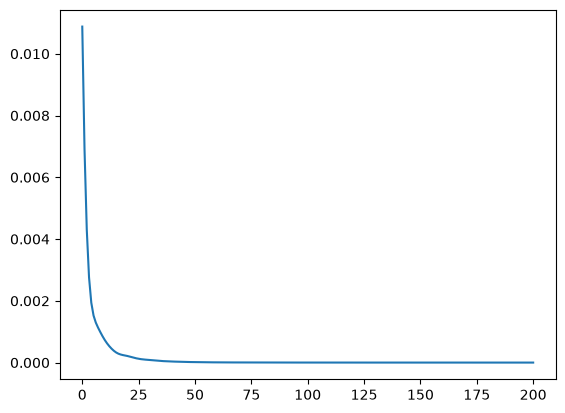

In [108]:
plt.plot(test_out[1])

In [109]:
test_out[1][-1]

5.960464477539062e-07

In [110]:
test_out[3]

np.complex64(9.706689e-13+0j)

In [111]:
test_out[4]

np.complex64(3.2448788e-12+0j)

In [112]:
test_out[5]

array([1.24805218e-01, 1.24802544e-01, 2.15178670e-04, 1.31778840e-04,
       1.26728129e-04, 1.00041045e-04, 8.83357047e-05, 6.66576688e-05,
       6.39630757e-05, 5.84895793e-05, 5.70409355e-05, 5.33722468e-05,
       5.27836131e-05, 4.76752214e-05, 4.28239176e-05, 4.16048282e-05,
       3.94820459e-05, 3.84589746e-05, 3.72934889e-05, 3.69395935e-05,
       3.44062723e-05, 3.42987229e-05, 3.28814081e-05, 3.09763983e-05,
       3.01418805e-05, 2.97106983e-05, 2.94210013e-05, 2.68617170e-05,
       2.59694070e-05, 2.53822230e-05, 2.44882889e-05, 2.32256421e-05,
       2.27946614e-05, 2.19765187e-05, 2.10369674e-05, 2.05660932e-05,
       2.04536276e-05, 1.89162850e-05, 1.82431113e-05, 1.76695022e-05,
       1.73712255e-05, 1.64387467e-05, 1.60998969e-05, 1.58287948e-05,
       1.57862215e-05, 1.49800442e-05, 1.44375798e-05, 1.39225483e-05,
       1.38681737e-05, 1.30039145e-05, 1.26539578e-05, 1.25128737e-05,
       1.18656226e-05, 1.18652746e-05, 1.11377444e-05, 1.09615329e-05,
      

In [113]:
test_out[6], test_out[7] 

(np.complex128(-0.9917522017853058+1.734723475976807e-17j),
 np.complex128(-0.9917521875385908+1.249590875218587e-09j))

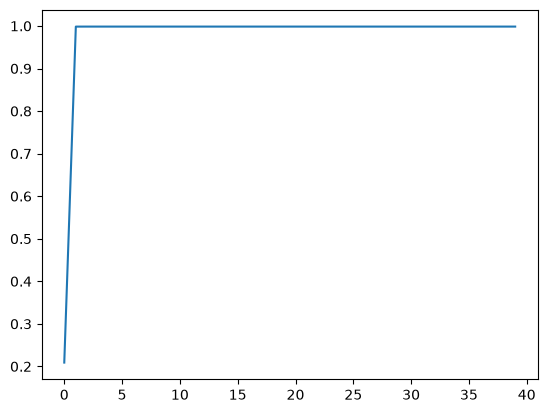

In [114]:
plt.plot(test_out[8])

In [115]:
test_out[9]

[[np.float32(0.547437),
  np.float32(1.0089436),
  array([3.53552877e-01, 3.53552862e-01, 3.32410573e-04, 2.99546533e-04,
         2.49311569e-04, 2.15670864e-04, 2.13057228e-04, 1.98858167e-04,
         1.67863760e-04, 1.58573806e-04, 1.26173059e-04, 1.24016895e-04,
         1.22643077e-04, 1.19648405e-04, 1.17202166e-04, 1.13749946e-04,
         9.60322305e-05, 9.26974887e-05, 8.43593309e-05, 8.22762527e-05,
         7.19608573e-05, 7.10085569e-05, 6.68719986e-05, 6.62310790e-05,
         6.28569953e-05, 5.73879474e-05, 5.26263612e-05, 4.91296274e-05,
         4.61904997e-05, 4.47267427e-05, 4.03049372e-05, 3.86223791e-05,
         3.65618294e-05, 3.41644443e-05, 3.33504329e-05, 3.19489512e-05,
         3.10885974e-05, 2.82226789e-05, 2.77312841e-05, 2.51468552e-05,
         2.22336614e-05, 2.13822261e-05, 2.03352948e-05, 1.95388806e-05,
         1.80101093e-05, 1.67703698e-05, 1.47639138e-05, 1.27720111e-05,
         1.23545362e-05, 1.14364260e-05, 1.13588738e-05, 9.26427678e-06,
  

## Round 5 - Depth 2, offset 0, 20 sites, 4 defect sites, 3 site separation

In [116]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(5, 16)),
    'left_symmetry_sites': list(range(5, 10)),
    'right_symmetry_sites': list(range(10, 16)),
    'left_defect_sites': [5,6,7,8],
    'right_defect_sites': [12,13,14, 15]
}

In [117]:
depth=2
offset=0

In [118]:
psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [119]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)

In [126]:
test_out = extract_factorization_time_reversal_information(
    rand_psi,
    domains_dict
)

Tensor(shape=(16, 2, 4, 16, 16, 2, 4, 16), inds=('kl1', 'kl2', 'kr1', 'kr2', 'bl1', 'bl2', 'br1', 'br2'), tags=oset(['prod', 'CZ', 'Layer_0', 'Layer_1']), backend='numpy', dtype='complex128')


In [128]:
test_out[0]

array([0.1518404 , 0.12078186])

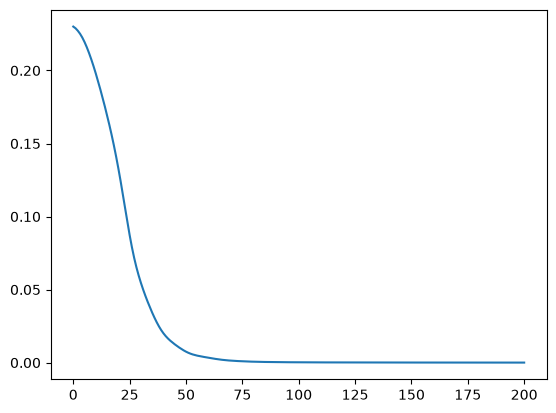

In [129]:
plt.plot(test_out[1])

In [130]:
test_out[1][-1]

4.100799560546875e-05

In [131]:
test_out[3]

np.complex64(3.7213128e-12+0j)

In [132]:
test_out[4]

np.complex64(3.3626127e-12+0j)

In [133]:
test_out[5]

array([1.41892569e-01, 1.18072351e-01, 5.82550469e-04, 5.52589825e-04,
       5.36169242e-04, 4.53957801e-04, 4.50706508e-04, 4.30392084e-04,
       3.94243728e-04, 3.88491385e-04, 3.59248572e-04, 3.45396436e-04,
       3.42265444e-04, 3.17789404e-04, 2.98216944e-04, 2.95907623e-04,
       2.76412985e-04, 2.72878174e-04, 2.68130287e-04, 2.62344880e-04,
       2.61834449e-04, 2.37695810e-04, 2.33374727e-04, 2.23980338e-04,
       2.19920230e-04, 2.14439459e-04, 2.07011063e-04, 2.02463746e-04,
       1.98739985e-04, 1.91177655e-04, 1.83086048e-04, 1.74941194e-04,
       1.73642591e-04, 1.68277572e-04, 1.67750946e-04, 1.62356131e-04,
       1.57998379e-04, 1.47840236e-04, 1.44301850e-04, 1.43301075e-04,
       1.41626618e-04, 1.30599876e-04, 1.30194541e-04, 1.25309518e-04,
       1.23515915e-04, 1.21311642e-04, 1.16521673e-04, 1.15198581e-04,
       1.11439163e-04, 1.10509698e-04, 1.06919633e-04, 1.05177197e-04,
       9.99031617e-05, 9.93654670e-05, 9.50238779e-05, 9.34243390e-05,
      

In [134]:
test_out[6], test_out[7] 

(np.complex128(-0.9999998557310429+2.300677981459387e-10j),
 np.complex128(-0.9999997878849569-1.0880427156467753e-08j))

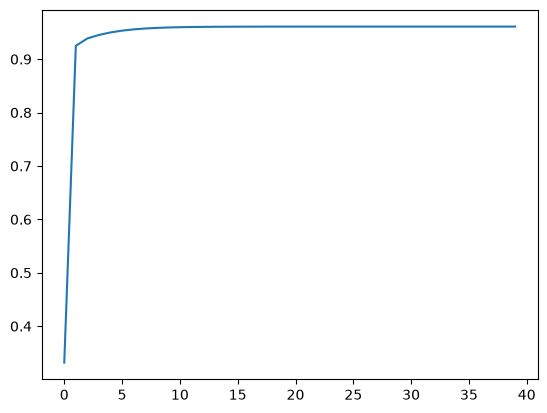

In [135]:
plt.plot(test_out[8])

In [136]:
test_out[9]

[[np.float32(0.9647354),
  np.float32(0.81591564),
  array([3.50857982e-01, 2.89361211e-01, 8.33068889e-04, 6.89001256e-04,
         6.68769864e-04, 6.38641755e-04, 6.35159035e-04, 6.04929328e-04,
         5.95541800e-04, 5.54010543e-04, 5.45375588e-04, 5.37555313e-04,
         4.97560485e-04, 4.94886415e-04, 4.59189937e-04, 4.36329941e-04,
         4.35662932e-04, 3.99634262e-04, 3.99312829e-04, 3.60800632e-04,
         3.45049451e-04, 3.25460275e-04, 2.97408979e-04, 2.93436588e-04,
         2.58561595e-04, 2.55891067e-04, 2.46888517e-04, 2.34887146e-04,
         2.18492959e-04, 2.16176344e-04, 2.09682934e-04, 1.81295081e-04,
         1.76479738e-04, 1.74096615e-04, 1.57026024e-04, 1.40667636e-04,
         1.32154367e-04, 1.28846687e-04, 1.18854304e-04, 1.16753706e-04,
         1.08333421e-04, 1.07918284e-04, 9.95082049e-05, 9.88068336e-05,
         9.24662326e-05, 9.11473973e-05, 8.32122584e-05, 8.22667524e-05,
         7.29034342e-05, 6.86751557e-05, 6.20652360e-05, 5.92005521e-05,


## Round 6 - Depth 2, offset 0, 20 sites, 4 defect sites, 4 site separation

In [137]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(4, 16)),
    'left_symmetry_sites': list(range(4, 10)),
    'right_symmetry_sites': list(range(10, 16)),
    'left_defect_sites': [4,5,6,7],
    'right_defect_sites': [12,13,14, 15]
}

In [138]:
depth=2
offset=0

In [139]:
psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [140]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)

In [141]:
test_out = extract_factorization_time_reversal_information(
    rand_psi,
    domains_dict
)

In [142]:
test_out[0]

array([0.13121806, 0.05419164])

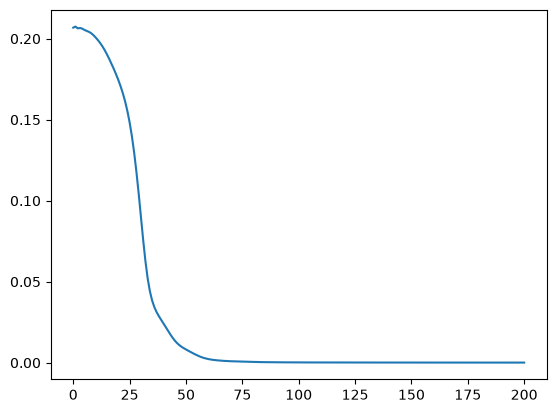

In [143]:
plt.plot(test_out[1])

In [144]:
test_out[1][-1]

8.091330528259277e-05

In [145]:
test_out[3]

np.complex64(3.0643578e-12+0j)

In [146]:
test_out[4]

np.complex64(5.104116e-12+0j)

In [147]:
test_out[5]

array([1.03674008e-01, 5.92681023e-02, 5.50992386e-04, 4.14099703e-04,
       2.45057593e-04, 2.19972436e-04, 2.08543878e-04, 2.05173300e-04,
       1.98511224e-04, 1.91152704e-04, 1.91113651e-04, 1.83325960e-04,
       1.72360353e-04, 1.71430190e-04, 1.60494684e-04, 1.58383962e-04,
       1.53083794e-04, 1.51250887e-04, 1.48577073e-04, 1.46376423e-04,
       1.45348598e-04, 1.42080306e-04, 1.37765513e-04, 1.32806355e-04,
       1.31987210e-04, 1.25371518e-04, 1.22277027e-04, 1.21177862e-04,
       1.16933600e-04, 1.15031453e-04, 1.11985225e-04, 1.04138469e-04,
       1.03597773e-04, 1.02176801e-04, 9.84526140e-05, 9.61192807e-05,
       9.53359743e-05, 9.37083259e-05, 9.31396938e-05, 8.99530896e-05,
       8.86061410e-05, 8.75159154e-05, 8.37539036e-05, 8.13339396e-05,
       8.11943267e-05, 7.83601237e-05, 7.51048958e-05, 7.48368333e-05,
       7.39972284e-05, 7.08468140e-05, 7.00035722e-05, 6.95196563e-05,
       6.60647981e-05, 6.49470354e-05, 6.34062349e-05, 6.31401573e-05,
      

In [148]:
test_out[6], test_out[7] 

(np.complex128(-0.9999999999999664-2.0362314820387972e-09j),
 np.complex128(-0.9999999999738898+2.2900851034957093e-08j))

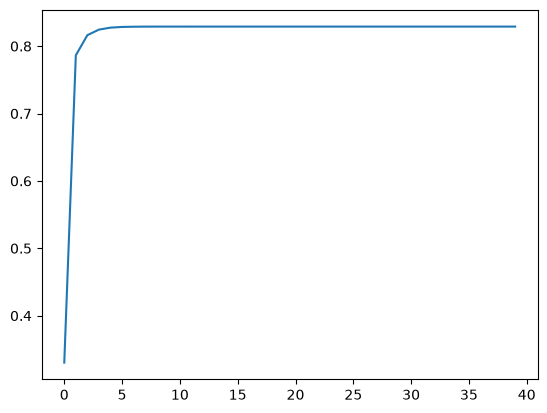

In [149]:
plt.plot(test_out[8])

In [150]:
test_out[9]

[[np.float32(0.74908566),
  np.float32(0.997722),
  array([2.40772529e-01, 1.52978204e-01, 5.03984156e-04, 4.26681719e-04,
         4.18126885e-04, 3.95140719e-04, 3.74611938e-04, 3.69673542e-04,
         3.49167372e-04, 3.40361512e-04, 3.26401854e-04, 3.16125205e-04,
         2.97925902e-04, 2.88338482e-04, 2.76891950e-04, 2.54870950e-04,
         2.54567907e-04, 2.45669178e-04, 2.40518894e-04, 2.24698975e-04,
         2.22115003e-04, 2.16420511e-04, 2.15004571e-04, 1.98457517e-04,
         1.84374037e-04, 1.81460703e-04, 1.71678935e-04, 1.67918728e-04,
         1.66641811e-04, 1.64591951e-04, 1.62054280e-04, 1.56435571e-04,
         1.54950958e-04, 1.47098950e-04, 1.39701728e-04, 1.37554543e-04,
         1.33358734e-04, 1.25151871e-04, 1.24867234e-04, 1.17185822e-04,
         1.12243933e-04, 1.11555535e-04, 1.07193124e-04, 1.04213996e-04,
         1.03788044e-04, 9.82369417e-05, 9.68277978e-05, 9.15482480e-05,
         8.63392592e-05, 8.30388312e-05, 7.69747453e-05, 7.45119231e-05,
 

## Round 7 - Depth 2, offset 0, 16 sites, 4 defect sites, 4 site separation

In [61]:
domains_dict = {
    'num_system_sites': 16,
    'symmetry_sites': list(range(2, 14)),
    'left_symmetry_sites': list(range(2, 8)),
    'right_symmetry_sites': list(range(8, 14)),
    'left_defect_sites': [2,3,4,5],
    'right_defect_sites': [10, 11, 12, 13]
}

In [62]:
depth=2
offset=0

In [63]:
psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [64]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)

In [65]:
test_out = extract_factorization_time_reversal_information(
    rand_psi,
    domains_dict
)

In [66]:
test_out[0]

array([0.14043403, 0.0822596 , 0.03403657, 0.02254127])

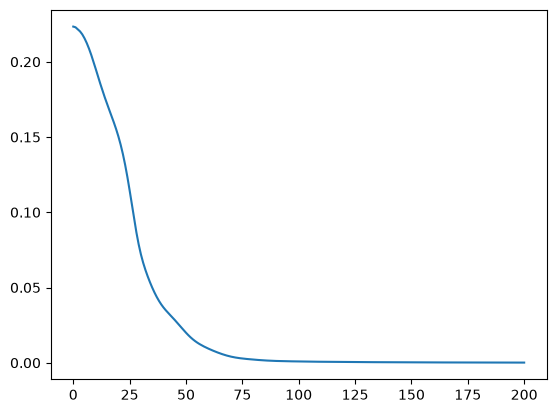

In [67]:
plt.plot(test_out[1])

In [68]:
test_out[1][-1]

0.00012120604515075684

In [159]:
test_out[3]

np.complex64(6.049011e-12+0j)

In [160]:
test_out[4]

np.complex64(3.149749e-12+0j)

In [161]:
test_out[5]

array([6.39174681e-02, 4.28938402e-02, 1.54695489e-02, 1.41462073e-02,
       9.19749429e-03, 7.31186913e-03, 4.52741268e-03, 2.58433343e-03,
       5.28451624e-04, 4.37718558e-04, 4.02274418e-04, 3.69524296e-04,
       3.63197142e-04, 3.33821595e-04, 3.28218432e-04, 2.93155862e-04,
       2.79301816e-04, 2.75644053e-04, 2.59472225e-04, 2.40983210e-04,
       2.31846797e-04, 2.30465289e-04, 2.20662599e-04, 2.04115187e-04,
       1.97596615e-04, 1.93881697e-04, 1.88723093e-04, 1.88502730e-04,
       1.83054872e-04, 1.73682821e-04, 1.65591399e-04, 1.60768222e-04,
       1.58737438e-04, 1.53444416e-04, 1.48989064e-04, 1.43785640e-04,
       1.42505705e-04, 1.36870043e-04, 1.34365370e-04, 1.25520188e-04,
       1.24298792e-04, 1.23627404e-04, 1.20308165e-04, 1.13886670e-04,
       1.10516300e-04, 1.07242038e-04, 1.05333615e-04, 1.02722363e-04,
       9.81112386e-05, 9.40465191e-05, 9.12108113e-05, 9.01561090e-05,
       8.83982511e-05, 8.59672795e-05, 8.47204477e-05, 8.29623365e-05,
      

In [162]:
test_out[6], test_out[7] 

(np.complex128(-0.999999999998987-1.2842695545911553e-08j),
 np.complex128(-0.9999999999999104+9.627511843302017e-10j))

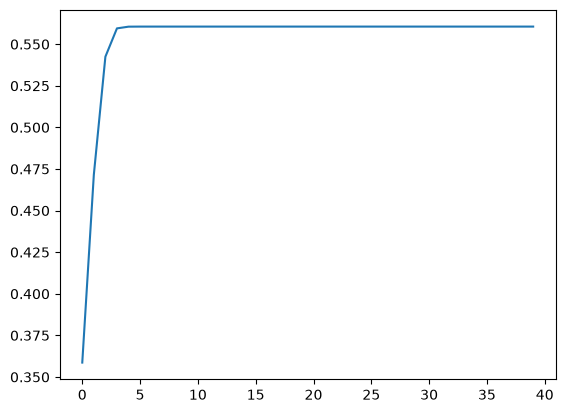

In [163]:
plt.plot(test_out[8])

In [164]:
test_out[9]

[[np.float32(1.0504112),
  np.float32(0.7258452),
  array([2.38717632e-01, 1.26596497e-01, 6.71543615e-02, 6.48178540e-02,
         3.47545821e-02, 3.39930333e-02, 1.78097096e-02, 9.49182067e-03,
         1.02069340e-03, 8.19624034e-04, 6.83330035e-04, 6.01813223e-04,
         5.40754817e-04, 5.36093948e-04, 4.79266304e-04, 4.24637114e-04,
         3.90044343e-04, 3.54298927e-04, 3.52746827e-04, 3.22070623e-04,
         2.91486265e-04, 2.77005152e-04, 2.74266777e-04, 2.46326310e-04,
         2.35868790e-04, 2.22206066e-04, 2.15943971e-04, 2.11928219e-04,
         2.01892456e-04, 1.90138614e-04, 1.83618865e-04, 1.80361610e-04,
         1.69057671e-04, 1.60519996e-04, 1.56251340e-04, 1.48957404e-04,
         1.47405344e-04, 1.40762801e-04, 1.31492959e-04, 1.30120342e-04,
         1.26735916e-04, 1.26428935e-04, 1.19887102e-04, 1.14623087e-04,
         1.12280911e-04, 1.06480506e-04, 1.04145087e-04, 1.00871065e-04,
         9.03258525e-05, 8.93031296e-05, 8.74970084e-05, 8.50849223e-05,
 

# Analysis

In [69]:
depth=2
offset=0

In [75]:
num_random_states=10

In [76]:
domains_dict = {
    'num_system_sites': 16,
    'symmetry_sites': list(range(2, 14)),
    'left_symmetry_sites': list(range(2, 8)),
    'right_symmetry_sites': list(range(8, 14)),
    'left_defect_sites': [2,3,4,5],
    'right_defect_sites': [10, 11, 12, 13]
}

In [77]:
out = list()

for _ in tqdm(range(num_random_states)):
    rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)
    data = extract_factorization_time_reversal_information(
        rand_psi,
        domains_dict
    )
    out.append(data)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [07:58<00:00, 47.85s/it]


## Check results

### $\rho$ Schmidt values

In [78]:
[l[0] for l in out]

[array([0.09519516, 0.05034923, 0.02699153, 0.01781413]),
 array([0.08409226, 0.04175051, 0.03439073, 0.02101969, 0.01728703,
        0.01101145, 0.01003308, 0.00408063, 0.0039636 , 0.00263716,
        0.0018303 , 0.00111723]),
 array([0.09389815, 0.0412838 , 0.03272086, 0.01056776]),
 array([0.11351739, 0.04047333, 0.02360852, 0.01012448]),
 array([0.14121328, 0.05886878, 0.02837453, 0.01269136]),
 array([0.0760494 , 0.0374741 , 0.02905341, 0.02307417, 0.01242928,
        0.00630695, 0.00617952, 0.00431403]),
 array([0.11829354, 0.0252629 , 0.0048693 , 0.00176395]),
 array([0.10981463, 0.03808928, 0.03419553, 0.01187051]),
 array([0.07711901, 0.03520568, 0.03319253, 0.02436766, 0.0239873 ,
        0.01641069]),
 array([0.08556902, 0.02521334, 0.01419812, 0.0044844 ])]

Fairly entangled in places...

### Factorization scores

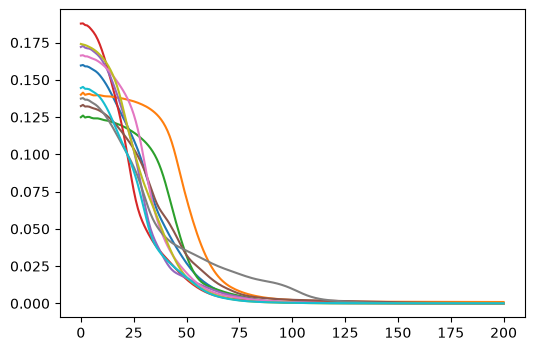

In [82]:
fig, ax = plt.subplots(figsize=(6,4))

for l in out:
    plt.plot(l[1])

In [83]:
final_scores = [
    l[1][-1] for l in out
]

In [84]:
final_scores

[5.6490302085876465e-05,
 0.0009362697601318359,
 1.4215707778930664e-05,
 0.0001150667667388916,
 9.125471115112305e-05,
 0.00019571185111999512,
 2.4452805519104004e-05,
 2.0965933799743652e-05,
 3.11434268951416e-05,
 5.1409006118774414e-05]

### Left right schmidt decomp diffs

In [85]:
left_right_diffs = [
    l[3:5]
    for l in out
]

In [86]:
left_right_diffs

[(np.complex64(2.7441899e-12+0j), np.complex64(2.9057672e-12+0j)),
 (np.complex64(4.8629776e-12+0j), np.complex64(5.556805e-12+0j)),
 (np.complex64(2.8554038e-12+0j), np.complex64(2.9548876e-12+0j)),
 (np.complex64(3.650789e-12+0j), np.complex64(3.1810006e-12+0j)),
 (np.complex64(4.4644934e-12+0j), np.complex64(1.7641574e-12+0j)),
 (np.complex64(3.099497e-12+0j), np.complex64(3.3511917e-12+0j)),
 (np.complex64(4.176204e-12+0j), np.complex64(5.074284e-12+0j)),
 (np.complex64(4.683832e-12+0j), np.complex64(2.4329599e-12+0j)),
 (np.complex64(4.9009624e-12+0j), np.complex64(5.535473e-12+0j)),
 (np.complex64(1.848432e-12+0j), np.complex64(3.2748968e-12+0j))]

### Left right schmidt vals, full $E$

In [89]:
[l[5][:5] for l in out]

[array([0.05591553, 0.05540515, 0.02151646, 0.01503982, 0.00982967]),
 array([0.08030644, 0.03789936, 0.03358409, 0.02247999, 0.01589084]),
 array([0.07979227, 0.03747563, 0.03024278, 0.01526083, 0.0031403 ]),
 array([0.08726712, 0.03366609, 0.02491179, 0.01047132, 0.00611081]),
 array([0.09739569, 0.0504232 , 0.01330504, 0.01294077, 0.00732478]),
 array([0.04657265, 0.03884437, 0.02683586, 0.0238075 , 0.02037843]),
 array([0.07912633, 0.03003322, 0.01865549, 0.00632364, 0.00383311]),
 array([0.08818756, 0.0455833 , 0.03426841, 0.01745693, 0.002901  ]),
 array([0.04377757, 0.03703267, 0.02914691, 0.01684266, 0.01582266]),
 array([0.07810296, 0.02514007, 0.01143286, 0.00355281, 0.00189821])]

### Left indices

In [90]:
[l[6] for l in out]

[np.complex128(-0.7300208558689033-7.389953722844456e-05j),
 np.complex128(-0.9999999999999118+8.462858608337953e-10j),
 np.complex128(-0.9999999999999448+6.1409551610491775e-09j),
 np.complex128(-0.9999999999998047+1.0023413835047457e-08j),
 np.complex128(-0.9999999999994275+2.29656975103687e-08j),
 np.complex128(0.9999977329036217-2.8538959699342392e-06j),
 np.complex128(-0.999999999999905+1.0908594834727059e-09j),
 np.complex128(-0.9999999999994245-1.3262708986605531e-09j),
 np.complex128(-0.9999999999998737+3.716620948501781e-09j),
 np.complex128(-0.9999999999999725-1.6269957187065032e-09j)]

### Right indices

In [91]:
[l[7] for l in out]

[np.complex128(-0.745647122374681-0.0007108902886198143j),
 np.complex128(-0.9999999999998763+2.954503974805789e-09j),
 np.complex128(-0.9999999999982201+3.6264649616590816e-10j),
 np.complex128(-0.9999999999999276-5.7229498084954145e-09j),
 np.complex128(-0.999999999999946-1.8400800050333288e-09j),
 np.complex128(0.9999977674537112-5.7169749425531324e-06j),
 np.complex128(-0.9999999999997752-7.889551456585764e-09j),
 np.complex128(-0.9999999999999292-1.0559113611252613e-08j),
 np.complex128(-0.9999999999998559+2.8246237515627826e-08j),
 np.complex128(-0.9999999999999579-3.741685294933461e-10j)]

### Overlaps

In [93]:
[l[8][-1] for l in out]

[np.float64(0.6198921628137528),
 np.float64(0.9568347261877174),
 np.float64(0.8639474829128047),
 np.float64(0.7662977494685894),
 np.float64(0.7023842604373415),
 np.float64(0.552882121108837),
 np.float64(0.6320191898531415),
 np.float64(0.8449700759693586),
 np.float64(0.584505886252696),
 np.float64(0.8950020254186373)]

### Restricted states

In [96]:
left_restricted_indices = [
    [l1[3] for l1 in l[9]]
    for l in out
]

In [97]:
left_restricted_indices

[[np.complex128(-0.9999559265467495-2.4288016652773692e-05j),
  np.complex128(-0.9994463614702034+3.749923584408675e-05j),
  np.complex128(-0.9999928421830373-8.438116362557979e-06j),
  np.complex128(-0.9999946929617526-2.1801359397777276e-06j)],
 [np.complex128(-1.000000119209289-2.453724584627892e-10j),
  np.complex128(-1.0000001415610311-7.921806544075594e-10j),
  np.complex128(-0.999999895691873+1.5611216624966673e-09j),
  np.complex128(-0.999999993480742+2.8487559533552087e-09j),
  np.complex128(-1.0000001965090632+1.334505783656681e-09j),
  np.complex128(-0.9999998183920975+2.5851655260922257e-09j),
  np.complex128(-1.0000001210719347+3.474428619809622e-09j),
  np.complex128(-1.000000031664967-1.7944965340077612e-09j),
  np.complex128(-0.9999998956918714-7.261344164843919e-10j),
  np.complex128(-0.999999905005098-1.805975896607137e-09j),
  np.complex128(-1.0000001136213539-3.078429143543726e-09j),
  np.complex128(-0.9999999161809678-2.248286626316265e-09j)],
 [np.complex128(-0.99

In [94]:
out[0][9]

[[np.float32(0.69989234),
  np.float32(0.7413764),
  array([2.21433997e-01, 1.97735283e-01, 5.57406393e-02, 4.77814940e-02,
         4.44098497e-02, 4.17695293e-02, 1.09391757e-02, 1.00762156e-02,
         1.78215670e-03, 1.59433738e-03, 1.41660152e-03, 1.15200240e-03,
         1.08558933e-03, 1.02513423e-03, 9.56191672e-04, 8.84138457e-04,
         7.79186559e-04, 7.21241988e-04, 6.95382088e-04, 6.75287258e-04,
         5.29706362e-04, 5.23902865e-04, 4.85615589e-04, 4.54397875e-04,
         4.32513407e-04, 4.04084549e-04, 4.00532105e-04, 3.69402135e-04,
         3.67409194e-04, 3.38487618e-04, 3.32531313e-04, 2.97382306e-04,
         2.91573638e-04, 2.67251871e-04, 2.59294884e-04, 2.48866853e-04,
         2.39269374e-04, 2.32917639e-04, 2.22615281e-04, 2.21891316e-04,
         2.11705496e-04, 1.95170493e-04, 1.91698034e-04, 1.84257911e-04,
         1.75121116e-04, 1.73166557e-04, 1.62961170e-04, 1.59322745e-04,
         1.53354211e-04, 1.46932582e-04, 1.43403940e-04, 1.34857388e-04,


# Conclusions
* The tensor network optimization is the bottleneck.